# Industrial Machine Failure Prediction

## Objective

Develop an end-to-end machine learning system to predict
industrial machine failure using sensor and operational data.

The project focuses on:
- severe class imbalance
- probability-based prediction
- threshold optimization
- model comparison
- model interpretability
- deployment

# 1. Import and Load Data

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

RANDOM_STATE = 42

In [5]:
df = pd.read_csv("data/ai4i2020.csv")

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Failure-mode indicator variables were excluded because they encode post-/near-failure information that would introduce target leakage into the predictive model.

# 2. Data Cleaning

In [6]:
leakage_features = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

drop_features = [
    "UDI",
    "Product ID",
    *leakage_features
]


df = df.drop(columns=drop_features)  # remove unimportant columns

# 3. Define y Target and X Features

In [7]:
target = "Machine failure"
X = df.drop(columns=[target])  # features
y = df[target]

print(X.shape, y.shape)

(10000, 6) (10000,)


In [8]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [9]:
y.value_counts() # We have imbalanced dataset

Machine failure
0    9661
1     339
Name: count, dtype: int64

# 4. Train-Validation-Test Split

In [10]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y, # This is important to maintain the same proportion of classes in the train and test sets
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    stratify=y_temp,
    random_state=42
)

In [11]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTest:")
print(y_test.value_counts())

Train: (6999, 6)
Validation: (1501, 6)
Test: (1500, 6)

Train:
Machine failure
0    6762
1     237
Name: count, dtype: int64

Validation:
Machine failure
0    1450
1      51
Name: count, dtype: int64

Test:
Machine failure
0    1449
1      51
Name: count, dtype: int64


TRAIN       70%

VALIDATION  15%

TEST        15%

In [12]:
X_train.columns.tolist()

['Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]']

In [13]:
X_train.dtypes

Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
dtype: object

Our X feature have numeric and String data. So we need to do data preprocessing

# 5. Data Preprocessing

In [14]:
numeric_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

categorical_features = ['Type']

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [16]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [17]:
X_train_processed.shape, X_val_processed.shape, X_test_processed.shape

((6999, 8), (1501, 8), (1500, 8))

# 6. Baseline Model 1 (Logistic Regression)

In [18]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

LR_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [19]:
y_val_pred_LR = LR_model.predict(X_val_processed)
y_val_proba_LR = LR_model.predict_proba(X_val_processed)[:, 1]

In [20]:
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_LR))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_LR))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba_LR))
print("PR-AUC:", average_precision_score(y_val, y_val_proba_LR))

Confusion Matrix:
[[1448    2]
 [  43    8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1450
           1       0.80      0.16      0.26        51

    accuracy                           0.97      1501
   macro avg       0.89      0.58      0.62      1501
weighted avg       0.97      0.97      0.96      1501

ROC-AUC: 0.8428127112914131
PR-AUC: 0.35648117871271845


# 7. Baseline Model 2 (Random Forest)

In [21]:
RF_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
RF_model.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [22]:
y_val_pred_RF = RF_model.predict(X_val_processed)

y_val_proba_RF = RF_model.predict_proba(
    X_val_processed
)[:, 1]

In [23]:
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_RF))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_RF))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_proba_RF))

print("PR-AUC:",
      average_precision_score(y_val, y_val_proba_RF))

Confusion Matrix:
[[1446    4]
 [  24   27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1450
           1       0.87      0.53      0.66        51

    accuracy                           0.98      1501
   macro avg       0.93      0.76      0.82      1501
weighted avg       0.98      0.98      0.98      1501

ROC-AUC: 0.9135564570655847
PR-AUC: 0.7412350465448643


# 8. Baseline Model 3 (XGBoost)

In [24]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

y_val_pred_xgb = xgb_model.predict(
    X_val_processed
)

y_val_proba_xgb = xgb_model.predict_proba(
    X_val_processed
)[:, 1]

In [25]:
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_xgb))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_proba_xgb))

print("PR-AUC:",
      average_precision_score(y_val, y_val_proba_xgb))

Confusion Matrix:
[[1444    6]
 [  20   31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1450
           1       0.84      0.61      0.70        51

    accuracy                           0.98      1501
   macro avg       0.91      0.80      0.85      1501
weighted avg       0.98      0.98      0.98      1501

ROC-AUC: 0.9381609195402297
PR-AUC: 0.7329906216222862


# 9. Baseline Comparation

In [26]:
baseline_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Precision': [
        precision_score(y_val, y_val_pred_LR),
        precision_score(y_val, y_val_pred_RF),
        precision_score(y_val, y_val_pred_xgb)
    ],
    'Recall': [
        recall_score(y_val, y_val_pred_LR),
        recall_score(y_val, y_val_pred_RF),
        recall_score(y_val, y_val_pred_xgb)
    ],
    'F1': [
        f1_score(y_val, y_val_pred_LR),
        f1_score(y_val, y_val_pred_RF),
        f1_score(y_val, y_val_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_val, y_val_proba_LR),
        roc_auc_score(y_val, y_val_proba_RF),
        roc_auc_score(y_val, y_val_proba_xgb)
    ],
    'PR-AUC': [
        average_precision_score(y_val, y_val_proba_LR),
        average_precision_score(y_val, y_val_proba_RF),
        average_precision_score(y_val, y_val_proba_xgb)
    ]
})

baseline_results

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.800000,0.156863,0.262295,0.842813,0.356481
1,Random Forest,0.870968,0.529412,0.658537,0.913556,0.741235
2,XGBoost,0.837838,0.607843,0.704545,0.938161,0.732991


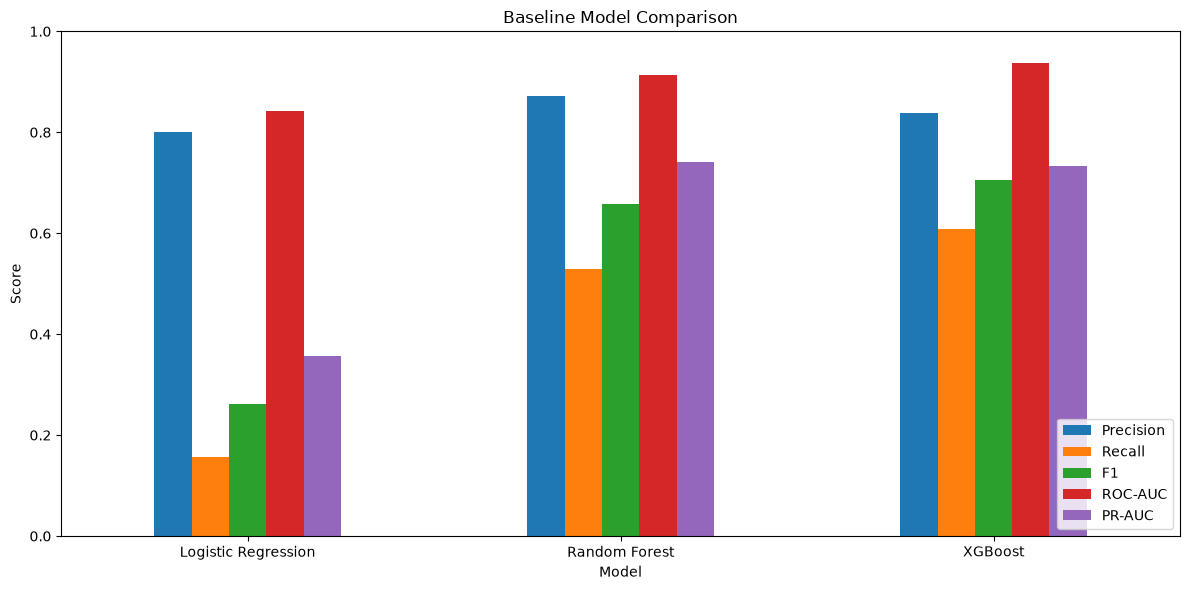

In [27]:
metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

baseline_results.set_index('Model')[metrics].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Baseline Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 10. Imbalance Dataset Handling (y Target)

In [28]:
y.value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

## Random Forest Class Weighting

In [29]:
rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(
    X_train_processed,
    y_train
)

y_val_pred_rf_balanced = rf_balanced.predict(
    X_val_processed
)

y_val_proba_rf_balanced = rf_balanced.predict_proba(
    X_val_processed
)[:, 1]

In [30]:
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf_balanced))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf_balanced))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_proba_rf_balanced))

print("PR-AUC:",
      average_precision_score(y_val, y_val_proba_rf_balanced))

Confusion Matrix:
[[1438   12]
 [  19   32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1450
           1       0.73      0.63      0.67        51

    accuracy                           0.98      1501
   macro avg       0.86      0.81      0.83      1501
weighted avg       0.98      0.98      0.98      1501

ROC-AUC: 0.929553752535497
PR-AUC: 0.7079068947557766


## XGBoost Class Weighting

In [31]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

scale_pos_weight

np.float64(28.531645569620252)

In [32]:
xgb_balanced = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_balanced.fit(
    X_train_processed,
    y_train
)

y_val_pred_xgb_balanced = xgb_balanced.predict(
    X_val_processed
)

y_val_proba_xgb_balanced = xgb_balanced.predict_proba(
    X_val_processed
)[:, 1]

In [33]:
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb_balanced))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_xgb_balanced))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_proba_xgb_balanced))

print("PR-AUC:",
      average_precision_score(y_val, y_val_proba_xgb_balanced))

Confusion Matrix:
[[1410   40]
 [  12   39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1450
           1       0.49      0.76      0.60        51

    accuracy                           0.97      1501
   macro avg       0.74      0.87      0.79      1501
weighted avg       0.97      0.97      0.97      1501

ROC-AUC: 0.9470047329276539
PR-AUC: 0.6850425063420854


## SMOTE + Random Forest

In [34]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [35]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Machine failure
0    6762
1     237
Name: count, dtype: int64

After SMOTE:
Machine failure
0    6762
1    6762
Name: count, dtype: int64


In [36]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

y_val_pred_rf_smote = rf_smote.predict(
    X_val_processed
)

y_val_proba_rf_smote = rf_smote.predict_proba(
    X_val_processed
)[:, 1]

In [37]:
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf_smote))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf_smote))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_proba_rf_smote))

print("PR-AUC:",
      average_precision_score(y_val, y_val_proba_rf_smote))

Confusion Matrix:
[[1417   33]
 [  15   36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1450
           1       0.52      0.71      0.60        51

    accuracy                           0.97      1501
   macro avg       0.76      0.84      0.79      1501
weighted avg       0.97      0.97      0.97      1501

ROC-AUC: 0.9400067613252197
PR-AUC: 0.7175038351427548


## SMOTE + XGBoost

In [38]:
xgb_smote = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_smote.fit(
    X_train_smote,
    y_train_smote
)

y_val_pred_xgb_smote = xgb_smote.predict(
    X_val_processed
)

y_val_proba_xgb_smote = xgb_smote.predict_proba(
    X_val_processed
)[:, 1]

In [39]:
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb_smote))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_xgb_smote))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_proba_xgb_smote))

print("PR-AUC:",
      average_precision_score(y_val, y_val_proba_xgb_smote))

Confusion Matrix:
[[1393   57]
 [  11   40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1450
           1       0.41      0.78      0.54        51

    accuracy                           0.95      1501
   macro avg       0.70      0.87      0.76      1501
weighted avg       0.97      0.95      0.96      1501

ROC-AUC: 0.935077755240027
PR-AUC: 0.7245912104648435


# 11. Final Comparation

In [40]:
results = []

def add_result(model_name, strategy, y_true, y_pred, y_proba):
    results.append({
        'Model': model_name,
        'Strategy': strategy,
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba)
    })


# Baseline
add_result(
    'Logistic Regression',
    'Baseline',
    y_val,
    y_val_pred_LR,
    y_val_proba_LR
)

add_result(
    'Random Forest',
    'Baseline',
    y_val,
    y_val_pred_RF,
    y_val_proba_RF
)

add_result(
    'XGBoost',
    'Baseline',
    y_val,
    y_val_pred_xgb,
    y_val_proba_xgb
)


# Class weighting
add_result(
    'Random Forest',
    'Class Weight',
    y_val,
    y_val_pred_rf_balanced,
    y_val_proba_rf_balanced
)

add_result(
    'XGBoost',
    'Scale Pos Weight',
    y_val,
    y_val_pred_xgb_balanced,
    y_val_proba_xgb_balanced
)


# SMOTE
add_result(
    'Random Forest',
    'SMOTE',
    y_val,
    y_val_pred_rf_smote,
    y_val_proba_rf_smote
)

add_result(
    'XGBoost',
    'SMOTE',
    y_val,
    y_val_pred_xgb_smote,
    y_val_proba_xgb_smote
)

results_df = pd.DataFrame(results)

results_df

,Model,Strategy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,Baseline,0.800000,0.156863,0.262295,0.842813,0.356481
1,Random Forest,Baseline,0.870968,0.529412,0.658537,0.913556,0.741235
2,XGBoost,Baseline,0.837838,0.607843,0.704545,0.938161,0.732991
3,Random Forest,Class Weight,0.727273,0.627451,0.673684,0.929554,0.707907
4,XGBoost,Scale Pos Weight,0.493671,0.764706,0.600000,0.947005,0.685043
5,Random Forest,SMOTE,0.521739,0.705882,0.600000,0.940007,0.717504
6,XGBoost,SMOTE,0.412371,0.784314,0.540541,0.935078,0.724591


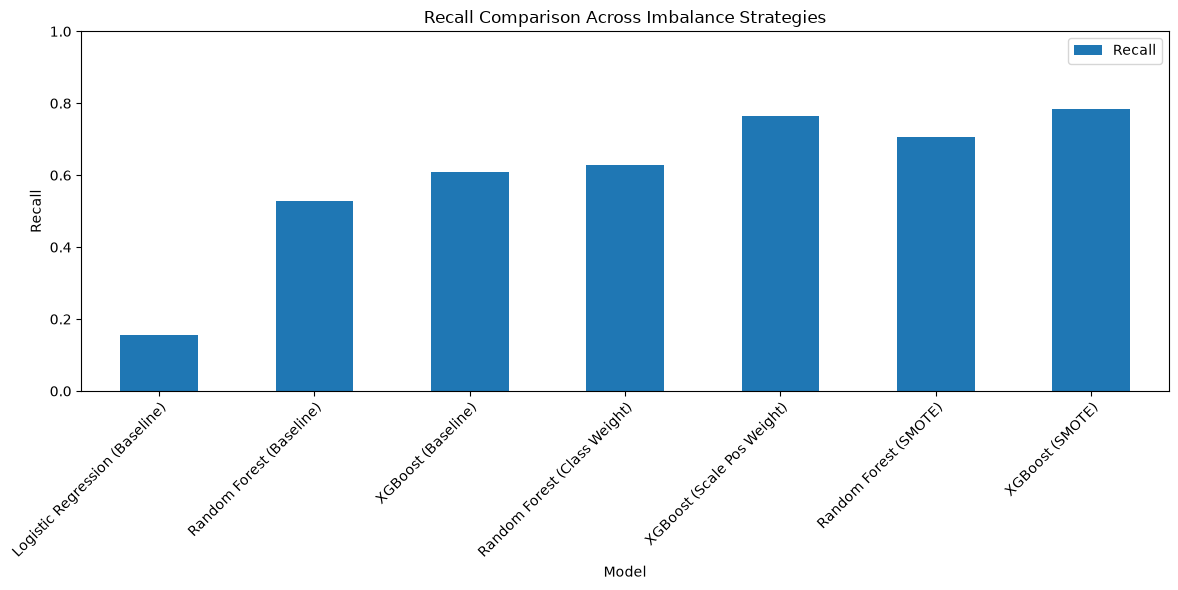

In [41]:
ax = results_df.plot(
    x='Model',
    y='Recall',
    kind='bar',
    figsize=(12, 6)
)

plt.title('Recall Comparison Across Imbalance Strategies')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right', labels=results_df['Model'] + ' (' + results_df['Strategy'] + ')', rotation_mode='anchor',ticks=ax.get_xticks())
plt.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.show()

In [42]:
results_df['Experiment'] = (
    results_df['Model'] + ' - ' + results_df['Strategy']
)

results_df

,Model,Strategy,Precision,Recall,F1,ROC-AUC,PR-AUC,Experiment
0,Logistic Regression,Baseline,0.800000,0.156863,0.262295,0.842813,0.356481,Logistic Regression - Baseline
1,Random Forest,Baseline,0.870968,0.529412,0.658537,0.913556,0.741235,Random Forest - Baseline
2,XGBoost,Baseline,0.837838,0.607843,0.704545,0.938161,0.732991,XGBoost - Baseline
3,Random Forest,Class Weight,0.727273,0.627451,0.673684,0.929554,0.707907,Random Forest - Class Weight
4,XGBoost,Scale Pos Weight,0.493671,0.764706,0.600000,0.947005,0.685043,XGBoost - Scale Pos Weight
5,Random Forest,SMOTE,0.521739,0.705882,0.600000,0.940007,0.717504,Random Forest - SMOTE
6,XGBoost,SMOTE,0.412371,0.784314,0.540541,0.935078,0.724591,XGBoost - SMOTE


The baseline models show that tree-based methods substantially outperform Logistic Regression. Random Forest provides the highest baseline PR-AUC (0.741), while XGBoost achieves a higher baseline F1-score (0.705) and ROC-AUC (0.938).

Handling class imbalance using class weighting or SMOTE generally increases recall but reduces precision. This demonstrates an important trade-off in predictive maintenance: increasing sensitivity to machine failures can also generate more false alarms.

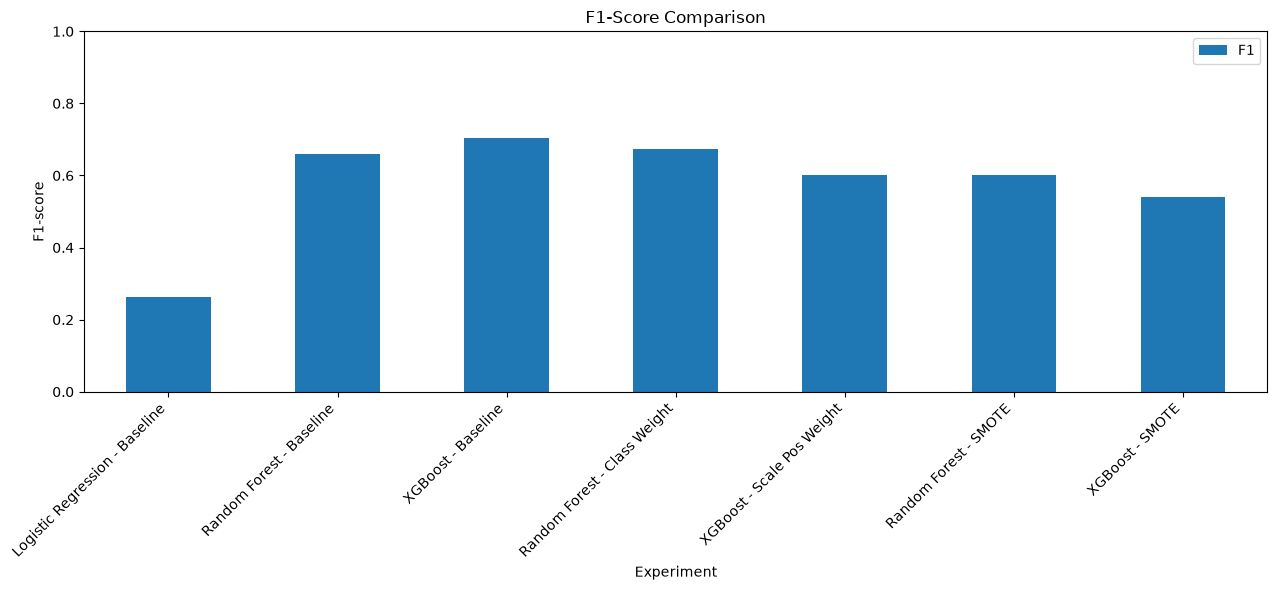

In [43]:
results_df.plot(
    x='Experiment',
    y='F1',
    kind='bar',
    figsize=(13, 6)
)

plt.title('F1-Score Comparison')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

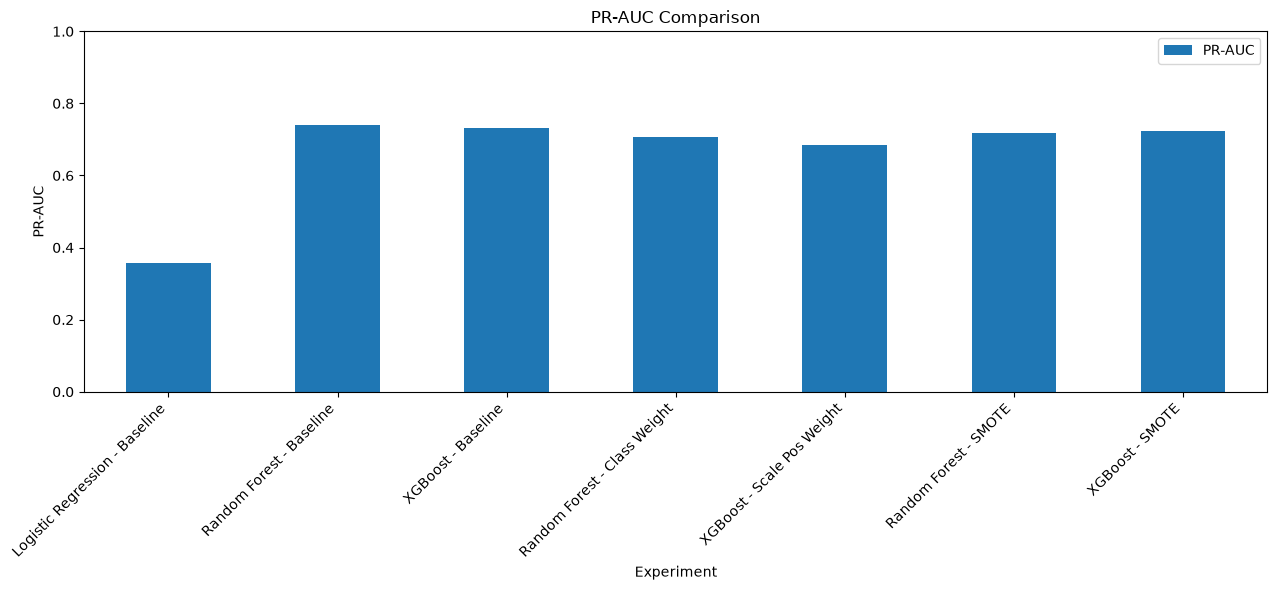

In [44]:
results_df.plot(
    x='Experiment',
    y='PR-AUC',
    kind='bar',
    figsize=(13, 6)
)

plt.title('PR-AUC Comparison')
plt.ylabel('PR-AUC')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

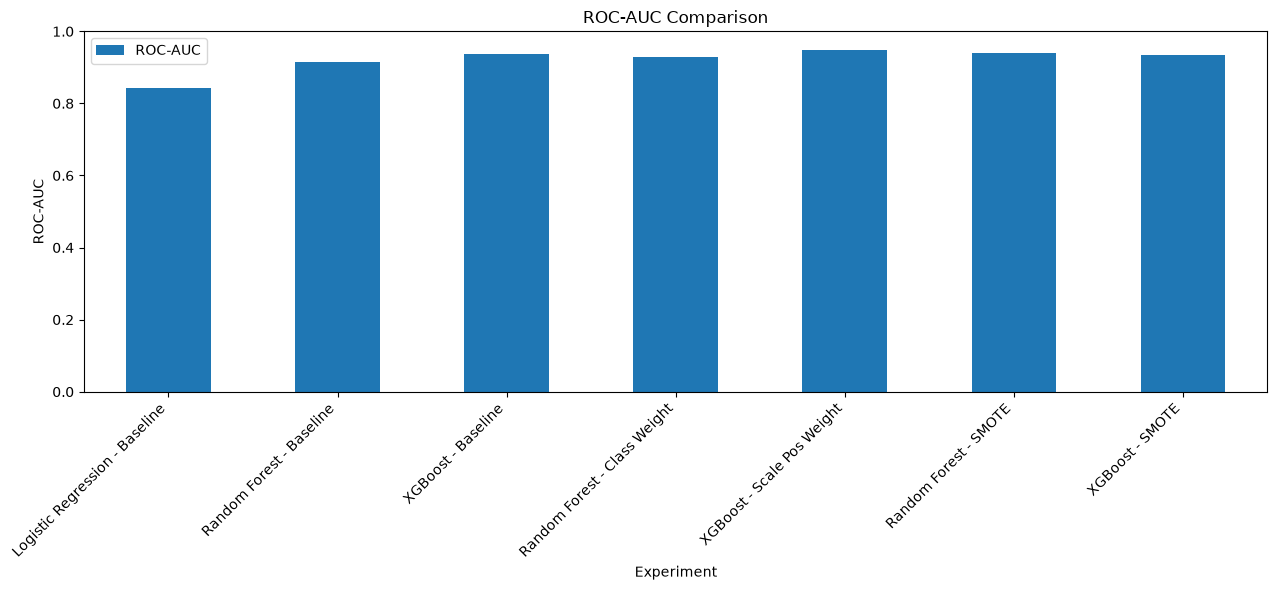

In [45]:
results_df.plot(
    x='Experiment',
    y='ROC-AUC',
    kind='bar',
    figsize=(13, 6)
)

plt.title('ROC-AUC Comparison')
plt.ylabel('ROC-AUC')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

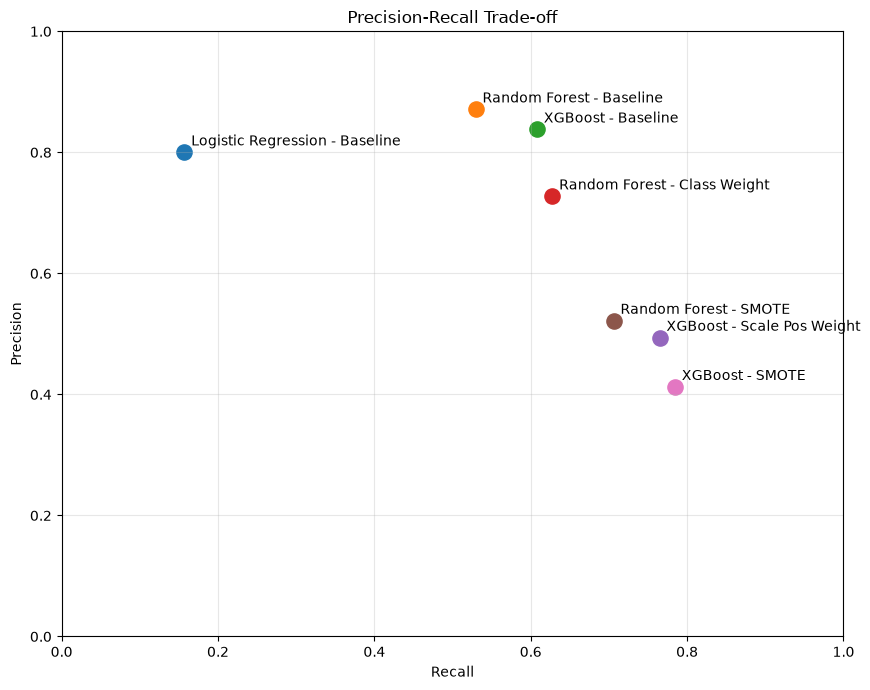

In [46]:
plt.figure(figsize=(9, 7))

for _, row in results_df.iterrows():
    plt.scatter(
        row['Recall'],
        row['Precision'],
        s=120
    )
    
    plt.annotate(
        row['Experiment'],
        (row['Recall'], row['Precision']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Trade-off')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

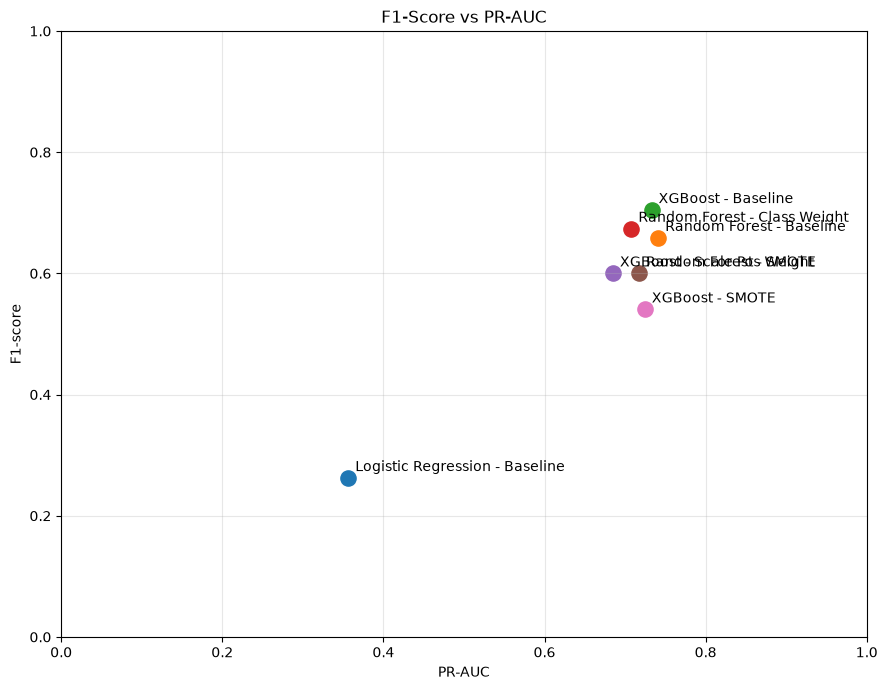

In [47]:
plt.figure(figsize=(9, 7))

for _, row in results_df.iterrows():
    plt.scatter(
        row['PR-AUC'],
        row['F1'],
        s=120
    )
    
    plt.annotate(
        row['Experiment'],
        (row['PR-AUC'], row['F1']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('PR-AUC')
plt.ylabel('F1-score')
plt.title('F1-Score vs PR-AUC')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 12. Hyperparameter Tuning


## Random Forest Hyperparameter Tuning

In [48]:
from sklearn.model_selection import RandomizedSearchCV

In [49]:
rf_param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [50]:
from sklearn.model_selection import RandomizedSearchCV

rf_base_for_tuning = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_random_search = RandomizedSearchCV(
    estimator=rf_base_for_tuning,
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring='average_precision',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to 

In [51]:
print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest CV PR-AUC:")
print(rf_random_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}

Best CV PR-AUC:
0.8161215321312929


In [52]:
rf_tuned = rf_random_search.best_estimator_

y_val_pred_rf_tuned = rf_tuned.predict(
    X_val_processed
)

y_val_proba_rf_tuned = rf_tuned.predict_proba(
    X_val_processed
)[:, 1]

In [53]:
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf_tuned))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf_tuned))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_proba_rf_tuned))

print("PR-AUC:",
      average_precision_score(y_val, y_val_proba_rf_tuned))

Confusion Matrix:
[[1445    5]
 [  18   33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1450
           1       0.87      0.65      0.74        51

    accuracy                           0.98      1501
   macro avg       0.93      0.82      0.87      1501
weighted avg       0.98      0.98      0.98      1501

ROC-AUC: 0.9308789722785666
PR-AUC: 0.7410473453539251


## XGBoost Hyperparameter Tuning

In [54]:
xgb_param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 2, 5, 10]
}

In [55]:
xgb_base_for_tuning = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base_for_tuning,
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring='average_precision',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function

In [56]:
print("Best Parameters:")
print(xgb_random_search.best_params_)

print("\nBest CV PR-AUC:")
print(xgb_random_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0.01, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 1.0}

Best CV PR-AUC:
0.7784249762318944


In [57]:
xgb_tuned = xgb_random_search.best_estimator_

y_val_pred_xgb_tuned = xgb_tuned.predict(X_val_processed)
y_val_proba_xgb_tuned = xgb_tuned.predict_proba(X_val_processed)[:, 1]

In [58]:
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb_tuned))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_xgb_tuned))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_proba_xgb_tuned))

print("PR-AUC:",
      average_precision_score(y_val, y_val_proba_xgb_tuned))

Confusion Matrix:
[[1444    6]
 [  22   29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1450
           1       0.83      0.57      0.67        51

    accuracy                           0.98      1501
   macro avg       0.91      0.78      0.83      1501
weighted avg       0.98      0.98      0.98      1501

ROC-AUC: 0.9461122379986477
PR-AUC: 0.7582334970440952


# 13. Threshold Tuning (Random Forest & XGBoost)

In [59]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    # RF
    y_pred_rf = (y_val_proba_rf_tuned >= threshold).astype(int)

    threshold_results.append({
        'Model': 'RF Tuned',
        'Threshold': threshold,
        'Precision': precision_score(y_val, y_pred_rf, zero_division=0),
        'Recall': recall_score(y_val, y_pred_rf, zero_division=0),
        'F1': f1_score(y_val, y_pred_rf, zero_division=0)
    })

    # XGBoost
    y_pred_xgb = (y_val_proba_xgb_tuned >= threshold).astype(int)

    threshold_results.append({
        'Model': 'XGBoost Tuned',
        'Threshold': threshold,
        'Precision': precision_score(y_val, y_pred_xgb, zero_division=0),
        'Recall': recall_score(y_val, y_pred_xgb, zero_division=0),
        'F1': f1_score(y_val, y_pred_xgb, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Model,Threshold,Precision,Recall,F1
0,RF Tuned,0.10,0.394231,0.803922,0.529032
1,XGBoost Tuned,0.10,0.455556,0.803922,0.581560
2,RF Tuned,0.15,0.540541,0.784314,0.640000
3,XGBoost Tuned,0.15,0.547945,0.784314,0.645161
4,RF Tuned,0.20,0.627119,0.725490,0.672727
5,XGBoost Tuned,0.20,0.579710,0.784314,0.666667
6,RF Tuned,0.25,0.660377,0.686275,0.673077
7,XGBoost Tuned,0.25,0.633333,0.745098,0.684685
8,RF Tuned,0.30,0.739130,0.666667,0.701031
9,XGBoost Tuned,0.30,0.685185,0.725490,0.704762


In [60]:
best_thresholds = (
    threshold_df
    .loc[threshold_df.groupby('Model')['F1'].idxmax()]
)

best_thresholds

,Model,Threshold,Precision,Recall,F1
12,RF Tuned,0.40,0.85,0.666667,0.747253
11,XGBoost Tuned,0.35,0.72,0.705882,0.712871


In [61]:
threshold = 0.40

y_val_pred_rf_final_candidate = (
    y_val_proba_rf_tuned >= threshold
).astype(int)

print("RF Tuned @ 0.40")
print(confusion_matrix(y_val, y_val_pred_rf_final_candidate))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_rf_final_candidate
    )
)

RF Tuned @ 0.40
[[1444    6]
 [  17   34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1450
           1       0.85      0.67      0.75        51

    accuracy                           0.98      1501
   macro avg       0.92      0.83      0.87      1501
weighted avg       0.98      0.98      0.98      1501



In [62]:
threshold = 0.35

y_val_pred_xgb_final_candidate = (
    y_val_proba_xgb_tuned >= threshold
).astype(int)

print("XGBoost Tuned @ 0.35")
print(confusion_matrix(y_val, y_val_pred_xgb_final_candidate))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_xgb_final_candidate
    )
)

XGBoost Tuned @ 0.35
[[1436   14]
 [  15   36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1450
           1       0.72      0.71      0.71        51

    accuracy                           0.98      1501
   macro avg       0.85      0.85      0.85      1501
weighted avg       0.98      0.98      0.98      1501



# 14. Model Selection

In [63]:

# Define model predictions and thresholds
models = [
    {
        'Model': 'Logistic Regression',
        'Strategy': 'Baseline',
        'Threshold': 0.50,
        'Proba': y_val_proba_LR
    },
    {
        'Model': 'Random Forest',
        'Strategy': 'Baseline',
        'Threshold': 0.50,
        'Proba': y_val_proba_RF
    },
    {
        'Model': 'XGBoost',
        'Strategy': 'Baseline',
        'Threshold': 0.50,
        'Proba': y_val_proba_xgb
    },
    {
        'Model': 'Random Forest',
        'Strategy': 'Class Weight',
        'Threshold': 0.50,
        'Proba': y_val_proba_rf_balanced
    },
    {
        'Model': 'XGBoost',
        'Strategy': 'Scale Pos Weight',
        'Threshold': 0.50,
        'Proba': y_val_proba_xgb_balanced
    },
    {
        'Model': 'Random Forest',
        'Strategy': 'SMOTE',
        'Threshold': 0.50,
        'Proba': y_val_proba_rf_smote
    },
    {
        'Model': 'XGBoost',
        'Strategy': 'SMOTE',
        'Threshold': 0.50,
        'Proba': y_val_proba_xgb_smote
    },
    {
        'Model': 'Random Forest',
        'Strategy': 'Tuned + Threshold',
        'Threshold': 0.40,
        'Proba': y_val_proba_rf_tuned
    },
    {
        'Model': 'XGBoost',
        'Strategy': 'Tuned + Threshold',
        'Threshold': 0.35,
        'Proba': y_val_proba_xgb_tuned
    }
]


# Calculate validation metrics
results = []

for item in models:

    y_pred = (item['Proba'] >= item['Threshold']).astype(int)

    results.append({
        'Model': item['Model'],
        'Strategy': item['Strategy'],
        'Threshold': item['Threshold'],
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc_score(y_val, item['Proba']),
        'PR-AUC': average_precision_score(y_val, item['Proba'])
    })


# Create final comparison table
final_comparison = pd.DataFrame(results)

# Round metrics for readability
metric_columns = [
    'Precision',
    'Recall',
    'F1',
    'ROC-AUC',
    'PR-AUC'
]

final_comparison[metric_columns] = (
    final_comparison[metric_columns].round(3)
)

# Display
final_comparison

,Model,Strategy,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,Baseline,0.50,0.800,0.157,0.262,0.843,0.356
1,Random Forest,Baseline,0.50,0.871,0.529,0.659,0.914,0.741
2,XGBoost,Baseline,0.50,0.838,0.608,0.705,0.938,0.733
3,Random Forest,Class Weight,0.50,0.727,0.627,0.674,0.930,0.708
4,XGBoost,Scale Pos Weight,0.50,0.494,0.765,0.600,0.947,0.685
5,Random Forest,SMOTE,0.50,0.529,0.725,0.612,0.940,0.718
6,XGBoost,SMOTE,0.50,0.412,0.784,0.541,0.935,0.725
7,Random Forest,Tuned + Threshold,0.40,0.850,0.667,0.747,0.931,0.741
8,XGBoost,Tuned + Threshold,0.35,0.720,0.706,0.713,0.946,0.758


Model Selection: The tuned Random Forest with a threshold of 0.40 was selected as the final candidate based on an F1-oriented objective. It achieved 0.850 precision, 0.667 recall, and 0.747 F1-score on the validation set, providing a balanced trade-off between detecting machine failures and minimizing false alarms.

Tuned XGBoost achieved a higher PR-AUC (0.758) and slightly higher recall (0.706), but generated more false alarms and achieved a lower F1-score (0.713) at its optimized threshold of 0.35. Therefore, XGBoost is retained as an alternative for scenarios where failure detection is prioritized over minimizing false alarms.

The test set remains untouched and will be used only for the final evaluation of the selected model.

# 15. Retrain Final Model on Train + Validation

In [64]:
# Combine training and validation sets

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

print("Training + Validation shape:", X_train_val.shape)
print("Target distribution:")
print(y_train_val.value_counts())

Training + Validation shape: (8500, 6)
Target distribution:
Machine failure
0    8212
1     288
Name: count, dtype: int64


In [65]:
# Fit final preprocessing on Train + Validation

preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

X_train_val_processed = preprocessor_final.fit_transform(X_train_val)

X_test_processed = preprocessor_final.transform(X_test)

print("Processed Train + Validation:", X_train_val_processed.shape)
print("Processed Test:", X_test_processed.shape)

Processed Train + Validation: (8500, 8)
Processed Test: (1500, 8)


In [66]:
rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_val_processed, y_train_val)

print("Final Random Forest trained successfully.")

Final Random Forest trained successfully.


In [67]:
# Generate probability predictions on the untouched test set

y_test_proba = rf_final.predict_proba(X_test_processed)[:, 1]

# Apply the locked threshold selected from validation
final_threshold = 0.40

y_test_pred = (y_test_proba >= final_threshold).astype(int)

print("Test predictions generated successfully.")
print("Threshold:", final_threshold)

Test predictions generated successfully.
Threshold: 0.4


In [68]:

print("Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print("PR-AUC:", average_precision_score(y_test, y_test_proba))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1449
           1       0.82      0.82      0.82        51

    accuracy                           0.99      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.99      0.99      0.99      1500

Confusion Matrix:
[[1440    9]
 [   9   42]]
ROC-AUC: 0.9722594351750362
PR-AUC: 0.8826309690940783


## Duplicate and Leakage Check

In [69]:
# Check exact duplicate rows across train, validation, and test sets

train_rows = set(map(tuple, X_train.values))
val_rows = set(map(tuple, X_val.values))
test_rows = set(map(tuple, X_test.values))

print("Train ∩ Validation:", len(train_rows & val_rows))
print("Train ∩ Test:", len(train_rows & test_rows))
print("Validation ∩ Test:", len(val_rows & test_rows))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [70]:
print("Duplicate rows in Train:", X_train.duplicated().sum())
print("Duplicate rows in Validation:", X_val.duplicated().sum())
print("Duplicate rows in Test:", X_test.duplicated().sum())

Duplicate rows in Train: 0
Duplicate rows in Validation: 0
Duplicate rows in Test: 0


In [71]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

cv_results = cross_validate(
    rf_final,
    X_train_val_processed,
    y_train_val,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [72]:
cv_summary = pd.DataFrame({
    'Metric': [
        'Precision',
        'Recall',
        'F1',
        'ROC-AUC',
        'PR-AUC'
    ],
    'Mean': [
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_roc_auc'].mean(),
        cv_results['test_pr_auc'].mean()
    ],
    'Std': [
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_f1'].std(),
        cv_results['test_roc_auc'].std(),
        cv_results['test_pr_auc'].std()
    ]
})

cv_summary.round(3)

,Metric,Mean,Std
0,Precision,0.867,0.047
1,Recall,0.653,0.050
2,F1,0.744,0.041
3,ROC-AUC,0.973,0.009
4,PR-AUC,0.807,0.037


In [73]:

# Predictions on training data
y_train_val_proba = rf_final.predict_proba(X_train_val_processed)[:, 1]
y_train_val_pred = (y_train_val_proba >= 0.40).astype(int)

train_metrics = {
    'Precision': precision_score(y_train_val, y_train_val_pred),
    'Recall': recall_score(y_train_val, y_train_val_pred),
    'F1': f1_score(y_train_val, y_train_val_pred),
    'ROC-AUC': roc_auc_score(y_train_val, y_train_val_proba),
    'PR-AUC': average_precision_score(y_train_val, y_train_val_proba)
}

pd.DataFrame(
    train_metrics.items(),
    columns=['Metric', 'Train + Validation']
).round(3)

,Metric,Train + Validation
0,Precision,0.975
1,Recall,0.938
2,F1,0.956
3,ROC-AUC,1.000
4,PR-AUC,0.995


## Model Diagnostic

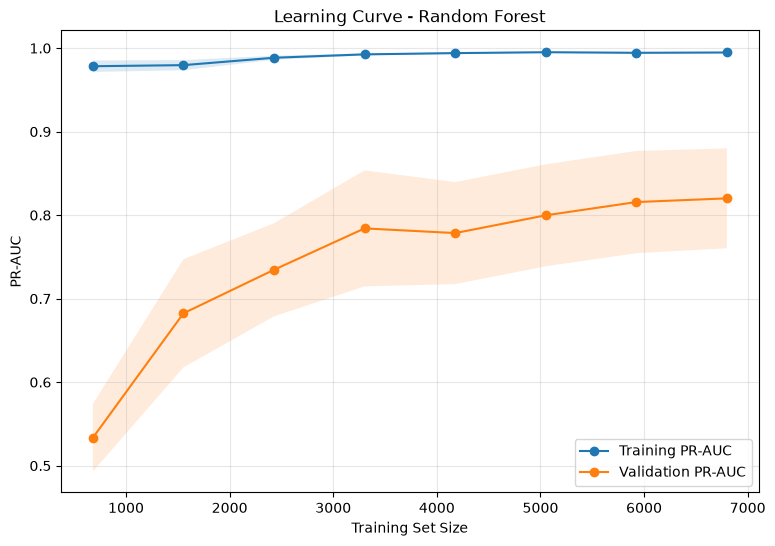

In [74]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=rf_final,
    X=X_train_val_processed,
    y=y_train_val,
    cv=5,
    scoring='average_precision',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(9, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training PR-AUC'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation PR-AUC'
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15
)

plt.xlabel('Training Set Size')
plt.ylabel('PR-AUC')
plt.title('Learning Curve - Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The learning curve revealed a noticeable gap between training and validation PR-AUC, indicating that the Random Forest fits the training data closely. However, 5-fold cross-validation and held-out test evaluation showed stable ROC-AUC performance, suggesting that the observed training gap did not result in severe generalization failure.

# 16. Test Error Analysis

In [75]:
# Test set error analysis

test_results = X_test.copy()

test_results['Actual'] = y_test.values
test_results['Predicted'] = y_test_pred
test_results['Failure_Probability'] = y_test_proba

# Identify prediction errors
test_errors = test_results[
    test_results['Actual'] != test_results['Predicted']
].copy()

print("Total test errors:", len(test_errors))

print(
    "False Positives:",
    ((test_errors['Actual'] == 0) &
     (test_errors['Predicted'] == 1)).sum()
)

print(
    "False Negatives:",
    ((test_errors['Actual'] == 1) &
     (test_errors['Predicted'] == 0)).sum()
)

test_errors

Total test errors: 18
False Positives: 9
False Negatives: 9


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Actual,Predicted,Failure_Probability
1833,L,297.8,307.3,1327,61.0,186,1,0,0.384222
3593,M,301.6,310.4,1377,44.9,161,0,1,0.521214
1996,M,298.4,308.0,1416,38.2,198,1,0,0.000000
1085,L,297.0,307.8,1385,56.4,202,1,0,0.194079
6127,L,300.9,310.9,1228,66.4,109,0,1,0.643149
4034,L,302.0,310.8,1615,29.0,235,1,0,0.127992
3695,L,302.2,311.3,1530,37.3,207,1,0,0.021952
4851,L,303.7,312.1,1363,51.8,90,1,0,0.318611
7087,L,300.6,310.3,1648,30.5,217,1,0,0.063500
5996,M,300.5,310.2,1386,48.2,225,0,1,0.489033


The final Random Forest produced 18 errors on the held-out test set, consisting of 9 false positives and 9 false negatives. False negatives occurred across a range of operating conditions, suggesting that prediction errors cannot be attributed to a single feature or simple operating regime. Several false positives exhibited combinations of high torque, rotational speed, or tool wear that were associated with elevated predicted failure probabilities despite the machines being labeled as non-failures. This indicates that the model captures complex interactions between operating variables but still has difficulty distinguishing some borderline operating conditions.

# 17. SHAP Analysis

In [76]:
import shap

d:\proyek\predictive-maintenance-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [79]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['num__Air temperature [K]', 'num__Process temperature [K]',
       'num__Rotational speed [rpm]', 'num__Torque [Nm]',
       'num__Tool wear [min]', 'cat__Type_H', 'cat__Type_L',
       'cat__Type_M'], dtype=object)

In [80]:
# Create SHAP TreeExplainer for the final Random Forest

explainer = shap.TreeExplainer(rf_final)

shap_values = explainer.shap_values(X_test_processed)

print(type(shap_values))

<class 'numpy.ndarray'>


In [81]:
print("X_test_processed shape:", X_test_processed.shape)

if isinstance(shap_values, list):
    print("Number of SHAP outputs:", len(shap_values))
    print("Class 0 shape:", shap_values[0].shape)
    print("Class 1 shape:", shap_values[1].shape)
else:
    print("SHAP shape:", shap_values.shape)

X_test_processed shape: (1500, 8)
SHAP shape: (1500, 8, 2)


In [82]:
# SHAP values for the failure class (class 1)

shap_values_failure = shap_values[:, :, 1]

print("SHAP failure shape:", shap_values_failure.shape)

SHAP failure shape: (1500, 8)


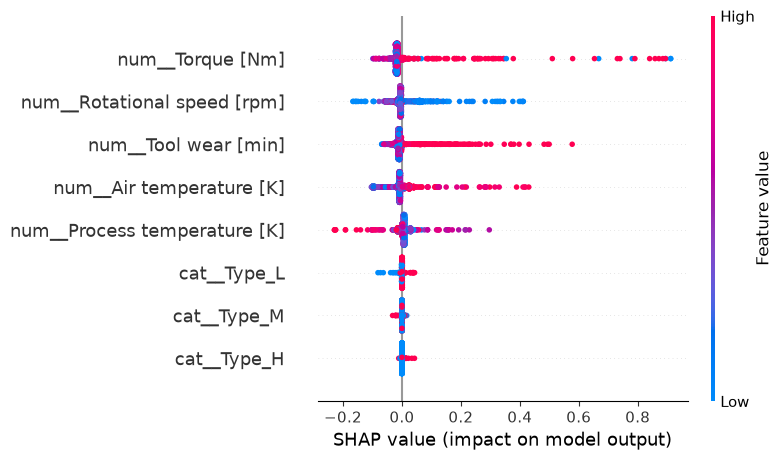

In [83]:
shap.summary_plot(
    shap_values_failure,
    X_test_processed,
    feature_names=feature_names,
    show=True
)

In [84]:
shap_importance = np.abs(shap_values_failure).mean(axis=0)

shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP value|': shap_importance
}).sort_values(
    'Mean |SHAP value|',
    ascending=False
)

shap_importance_df

,Feature,Mean |SHAP value|
3,num__Torque [Nm],0.032437
2,num__Rotational speed [rpm],0.022883
4,num__Tool wear [min],0.022851
0,num__Air temperature [K],0.022545
1,num__Process temperature [K],0.012826
6,cat__Type_L,0.001302
7,cat__Type_M,0.000465
5,cat__Type_H,0.000399


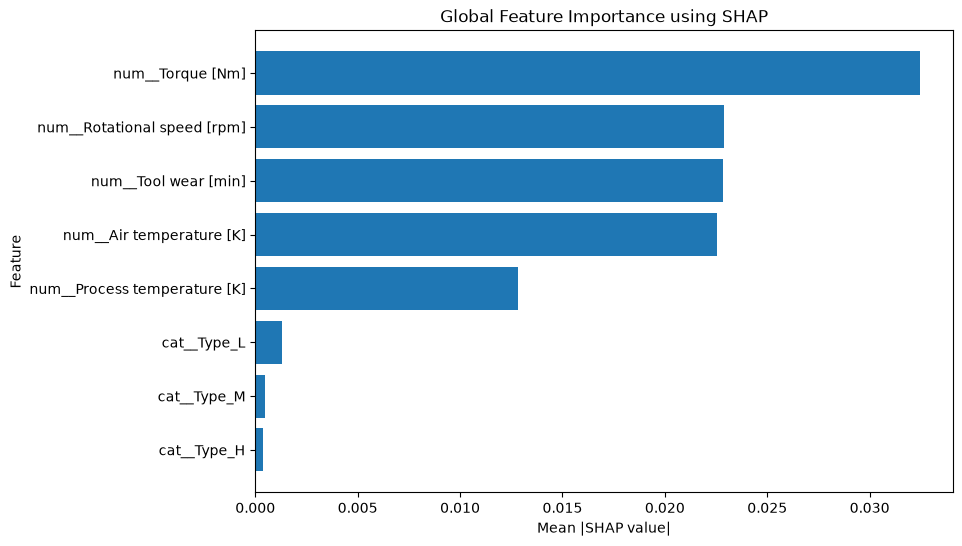

In [85]:
plt.figure(figsize=(9, 6))

plt.barh(
    shap_importance_df['Feature'],
    shap_importance_df['Mean |SHAP value|']
)

plt.xlabel('Mean |SHAP value|')
plt.ylabel('Feature')
plt.title('Global Feature Importance using SHAP')
plt.gca().invert_yaxis()

plt.show()

### Global SHAP Interpretation

The SHAP analysis shows that **Torque** is the most influential feature in predicting machine failure, followed by **Rotational speed** and **Tool wear**.

* **Torque:** Higher values generally contribute to higher predicted failure risk.
* **Rotational speed:** Its effect varies depending on the operating conditions, suggesting a non-linear relationship.
* **Tool wear:** Higher tool wear generally increases the predicted failure risk.
* **Air temperature:** Higher values tend to contribute positively to the failure prediction.
* **Process temperature:** Its contribution varies across observations.
* **Machine Type:** The three machine types have relatively small SHAP contributions compared with the numerical features.

Overall, the model relies mainly on **operational and wear-related features** when predicting machine failure.


In [86]:
# Select a false positive with high predicted failure probability

false_positives = test_results[
    (test_results['Actual'] == 0) &
    (test_results['Predicted'] == 1)
].copy()

selected_idx = false_positives['Failure_Probability'].idxmax()

print(false_positives.loc[selected_idx])

Type                             L
Air temperature [K]          301.6
Process temperature [K]      310.6
Rotational speed [rpm]        1222
Torque [Nm]                   70.0
Tool wear [min]                 62
Actual                           0
Predicted                        1
Failure_Probability        0.84755
Name: 6612, dtype: object


In [87]:
# Find the corresponding row in the processed test data

test_position = X_test.index.get_loc(selected_idx)

print("Test position:", test_position)

Test position: 1260


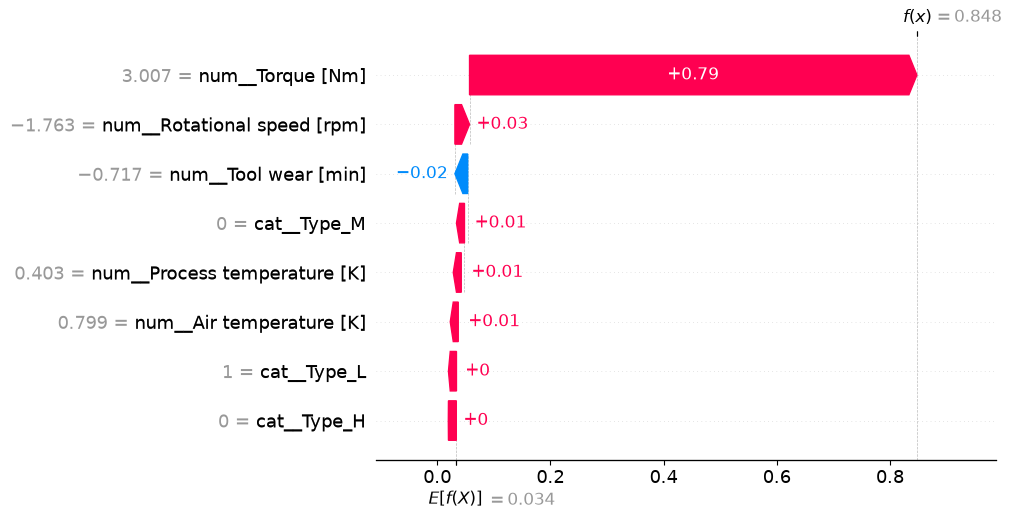

In [88]:
# Local SHAP explanation for the selected false positive

shap_explanation = shap.Explanation(
    values=shap_values_failure[test_position],
    base_values=explainer.expected_value[1],
    data=X_test_processed[test_position],
    feature_names=feature_names
)

shap.plots.waterfall(
    shap_explanation,
    max_display=8
)

### Local SHAP Interpretation

The selected case is a **false positive**: the machine did not actually fail, but the model predicted a high failure probability of **84.8%**.

* **Torque** has the largest positive SHAP contribution, strongly pushing the prediction toward failure.
* **Rotational speed** provides a small positive contribution.
* **Tool wear** provides a small negative contribution, slightly reducing the predicted failure risk.
* **Temperature features and Machine Type** have relatively small contributions.

This shows that the model mainly predicted failure because of the machine's **operating conditions, particularly its high torque**.


# Save Model

In [89]:
import joblib
import os

In [90]:
os.makedirs("models", exist_ok=True)

In [91]:
joblib.dump(rf_final, "models/rf_final.pkl")
joblib.dump(preprocessor, "models/preprocessor.pkl")
joblib.dump(0.40, "models/threshold.pkl")

print("Model, preprocessor, and threshold saved successfully.")

Model, preprocessor, and threshold saved successfully.


In [92]:
print(os.listdir("models"))

['preprocessor.pkl', 'rf_final.pkl', 'threshold.pkl']


In [93]:
rf_loaded = joblib.load("models/rf_final.pkl")
preprocessor_loaded = joblib.load("models/preprocessor.pkl")
threshold_loaded = joblib.load("models/threshold.pkl")

print("Model:", type(rf_loaded))
print("Preprocessor:", type(preprocessor_loaded))
print("Threshold:", threshold_loaded)

Model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Preprocessor: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Threshold: 0.4


In [94]:
X_test_loaded = preprocessor_loaded.transform(X_test)

y_test_proba_loaded = rf_loaded.predict_proba(X_test_loaded)[:, 1]

y_test_pred_loaded = (
    y_test_proba_loaded >= threshold_loaded
).astype(int)

print("Predictions:", y_test_pred_loaded[:10])
print("Probabilities:", y_test_proba_loaded[:10])

Predictions: [0 0 0 0 0 0 0 0 0 0]
Probabilities: [0.         0.         0.         0.         0.         0.
 0.08336111 0.07194841 0.         0.25902237]


In [95]:
validation_ranges = X_train_val[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ]
].agg(["min", "max"])

validation_ranges

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
min,295.3,305.7,1168,3.8,0
max,304.5,313.8,2886,76.6,253


In [96]:
test_input = pd.DataFrame({
    "Type": ["L"],
    "Air temperature [K]": [301.6],
    "Process temperature [K]": [310.6],
    "Rotational speed [rpm]": [1222],
    "Torque [Nm]": [70.0],
    "Tool wear [min]": [62]
})

test_input_processed = preprocessor.transform(test_input)

print(
    "Notebook probability:",
    rf_final.predict_proba(test_input_processed)[0, 1]
)

Notebook probability: 0.8475502645502646
